# 1.YOUTUBE GRAPH CONSTRUCTION

POST-POST HOMOPHILY GRAPH

In [4]:
import pandas as pd
import networkx as nx
from itertools import combinations

# =====================================================
# LOAD YOUTUBE GRAPH DATASET
# =====================================================

df = pd.read_csv(
    "../../data_preprocess/processed_data/graph_data/youtube_graph.csv"
)

print("=" * 60)
print("YOUTUBE GRAPH DATA")
print("=" * 60)

print(df.shape)

YOUTUBE GRAPH DATA
(18130, 32)


In [5]:
import pandas as pd
import numpy as np
import time

# Execution timer
overall_start = time.time()

# =====================================================
# 1. GENERATE NODES
# =====================================================
nodes_df = df.copy().rename(columns={"post_id": "Id"})
nodes_df["Label"] = nodes_df["Id"].astype(str)
node_cols = ["Id", "Label", "topic", "language", "media_type", "location", "followers", "popularity"]
nodes_df[node_cols].to_csv("youtube_node.csv", index=False, encoding='utf-8')

# =====================================================
# 2. GENERATE EDGES (DENSE HOMOPHILY STRATEGY)
# =====================================================
edges_list = []
features_to_connect = ['topic', 'language', 'media_type']

for feat in features_to_connect:
    print(f"Connecting via Homophily: {feat}...")
    
    # Group by feature
    for name, group in df.groupby(feat):
        ids = group['post_id'].values
        if len(ids) < 2:
            continue
            
        # Shuffle IDs to create diverse local connections within the group
        np.random.shuffle(ids)
        
        # Each node connects to K neighbors to form a dense cluster (Homophily)
        K = 3 
        for i in range(len(ids)):
            for j in range(1, K + 1):
                neighbor_idx = (i + j) % len(ids)
                source = ids[i]
                target = ids[neighbor_idx]
                
                if source != target:
                    edges_list.append({"Source": source, "Target": target, "Weight": 1})

# Convert to DataFrame and remove duplicates/self-loops
edges_df = pd.DataFrame(edges_list)
edges_df[['Source', 'Target']] = np.sort(edges_df[['Source', 'Target']], axis=1)
edges_df = edges_df.drop_duplicates()
edges_df = edges_df[edges_df['Source'] != edges_df['Target']]

# Export edges for Gephi
edges_df.to_csv("youtube_edge.csv", index=False, encoding='utf-8')

# =====================================================
# 3. EXECUTION SUMMARY
# =====================================================
print(f"\nNodes created: {len(nodes_df):,}")
print(f"Edges created: {len(edges_df):,}")
print("Strategy: Dense K-Nearest Homophily (K=3)")
print(f"Time: {round(time.time() - overall_start, 2)}s")

Connecting via Homophily: topic...
Connecting via Homophily: language...
Connecting via Homophily: media_type...

Nodes created: 18,130
Edges created: 163,104
Strategy: Dense K-Nearest Homophily (K=3)
Time: 0.98s


In [6]:
import pandas as pd

graph_df = pd.read_csv(
    "youtube-result-2.csv"
)

print("\n" + "=" * 60)
print("GRAPH FEATURES DATA")
print("=" * 60)

print(graph_df.shape)

print("\nColumns:")
print(graph_df.columns.tolist())


GRAPH FEATURES DATA
(18130, 16)

Columns:
['Id', 'Label', 'topic', 'language', 'media_type', 'location', 'followers', 'popularity', 'pageranks', 'modularity_class', 'Authority', 'Hub', 'indegree', 'outdegree', 'Degree', 'eigencentrality']


In [7]:
# SELECT ONLY USEFUL GRAPH FEATURES (Dựa trên cột thực tế từ Gephi)
# =====================================================

graph_features = graph_df[[
    "Id",                # Để merge dữ liệu
    "pageranks",         # Độ quan trọng/tầm ảnh hưởng của node
    "modularity_class",  # Cộng đồng (đặc trưng phân loại cực mạnh)
    "Degree",            # Tổng số kết nối (Broad Homophily)
    "eigencentrality"    # Độ quan trọng dựa trên chất lượng láng giềng
]]

# Đổi tên ID để đồng bộ với dataset gốc
graph_features = graph_features.rename(
    columns={
        "Id": "post_id"
    }
)

# Chuyển modularity_class sang kiểu số nguyên để XGBoost xử lý tốt hơn
graph_features["modularity_class"] = graph_features["modularity_class"].astype(int)

print("\nGraph Features Shape:")
print(graph_features.shape)
print("\nCác cột đặc trưng đồ thị đã chọn:")
print(graph_features.columns.tolist())


Graph Features Shape:
(18130, 5)

Các cột đặc trưng đồ thị đã chọn:
['post_id', 'pageranks', 'modularity_class', 'Degree', 'eigencentrality']


In [8]:
original_df = df.copy()

# =====================================================
# REMOVE DUPLICATES
# =====================================================

original_df = original_df.drop_duplicates(
    subset=["post_id"]
)

In [9]:
# MERGE POST_ID BACK TO TRAIN/TEST
# =====================================================
# We need mapping between rows
# =====================================================

# recreate metadata version
metadata_df = original_df.copy()

remove_cols = [
    
    "timestamp",
    "date",
    "platform",
    "likes",
    "shares",
    "comments",
    "views",
    "total_engagement",
    "engagement_rate_per_1k_followers",
    "viral_coefficient",
    "cross_platform_spread",
    "hours_since_post"
]

existing_remove_cols = [

    col for col in remove_cols
    if col in metadata_df.columns
]

metadata_df = metadata_df.drop(
    columns=existing_remove_cols
)


In [10]:
# =====================================================
# ONE-HOT ENCODING
# =====================================================

categorical_cols = [

    "topic",
    "language",
    "media_type",
    "sentiment_category",
    "location"
]

existing_categorical_cols = [

    col for col in categorical_cols
    if col in metadata_df.columns
]

metadata_df = pd.get_dummies(

    metadata_df,

    columns=existing_categorical_cols,

    drop_first=True
)


In [11]:
# LOAD YOUTUBE TRAIN / TEST
# =====================================================

train_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/youtube_train.csv"
)

test_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/youtube_test.csv"
)

print("=" * 60)
print("METADATA DATASETS")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

METADATA DATASETS
Train Shape: (14504, 58)
Test Shape : (3626, 58)


In [12]:
# MERGE TRAIN
# =====================================================

train_hybrid = train_df.merge(

    graph_features,

    on="post_id",
    how="left"
)

# =====================================================
# MERGE TEST
# =====================================================

test_hybrid = test_df.merge(

    graph_features,

    on="post_id",
    how="left"
)

In [13]:
# CHECK MISSING GRAPH FEATURES
# =====================================================

print("\n" + "=" * 60)
print("MISSING VALUES CHECK")
print("=" * 60)

print("\nTrain Missing:")

print(
    train_hybrid[
        [
            "pageranks",
            "Degree"
        ]
    ].isnull().sum()
)

print("\nTest Missing:")

print(
    test_hybrid[
        [
            "pageranks",
            "Degree"
        ]
    ].isnull().sum()
)



MISSING VALUES CHECK

Train Missing:
pageranks    0
Degree       0
dtype: int64

Test Missing:
pageranks    0
Degree       0
dtype: int64


In [14]:
# FILL MISSING VALUES
# =====================================================
# Một số node có thể không tồn tại trong file export từ Gephi 
# (do không có cạnh nối hoặc bị lọc bỏ), ta cần điền giá trị 0.
# =====================================================

# Chỉ giữ lại các cột thực tế bạn đã lấy từ Gephi
graph_cols = [
    "pageranks",
    "modularity_class",
    "Degree",
    "eigencentrality"
]

# Điền giá trị 0 cho các ô trống (NaN) sau khi Merge
train_hybrid[graph_cols] = train_hybrid[graph_cols].fillna(0)
test_hybrid[graph_cols] = test_hybrid[graph_cols].fillna(0)

# Đảm bảo modularity_class là số nguyên sau khi fillna
train_hybrid["modularity_class"] = train_hybrid["modularity_class"].astype(int)
test_hybrid["modularity_class"] = test_hybrid["modularity_class"].astype(int)

print("\n" + "=" * 60)
print("HYBRID DATASETS PREPARED")
print("=" * 60)

print(f"Train Hybrid Shape: {train_hybrid.shape}")
print(f"Test Hybrid Shape : {test_hybrid.shape}")

# Kiểm tra xem còn giá trị thiếu nào không
missing_after = train_hybrid[graph_cols].isnull().sum().sum()
print(f"Total missing values in graph features: {missing_after}")
print("=" * 60)


HYBRID DATASETS PREPARED
Train Hybrid Shape: (14504, 62)
Test Hybrid Shape : (3626, 62)
Total missing values in graph features: 0


In [15]:
# SAVE HYBRID DATASETS
# =====================================================

train_hybrid.to_csv(
    "youtube_hybrid_train.csv",
    index=False
)

test_hybrid.to_csv(
    "youtube_hybrid_test.csv",
    index=False
)

In [16]:
# =====================================================
# YOUTUBE HYBRID MODEL
# METADATA + GRAPH FEATURES
# =====================================================

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [17]:
# LOAD HYBRID DATASETS
# =====================================================

train_df = pd.read_csv(
    "youtube_hybrid_train.csv"
)

test_df = pd.read_csv(
    "youtube_hybrid_test.csv"
)

print("=" * 60)
print("HYBRID DATASETS")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

HYBRID DATASETS
Train Shape: (14504, 62)
Test Shape : (3626, 62)


In [18]:
# DROP ID COLUMNS
# =====================================================

drop_cols = [

    "post_id",
    "user_id"
]

existing_drop_cols = [

    col for col in drop_cols
    if col in train_df.columns
]

train_df = train_df.drop(
    columns=existing_drop_cols
)

test_df = test_df.drop(
    columns=existing_drop_cols
)

In [19]:
# SPLIT FEATURES / TARGET
# =====================================================

X_train = train_df.drop(
    columns=["popularity"]
)

y_train = train_df["popularity"]

X_test = test_df.drop(
    columns=["popularity"]
)

y_test = test_df["popularity"]

print("\nX_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)


X_train Shape: (14504, 59)
X_test Shape : (3626, 59)


In [20]:
# --- CODE XEM GIÁ TRỊ POPULARITY TẠI ĐÂY ---
print("\n" + "="*30)
print("PHÂN BỔ LỚP TRONG TẬP TRAIN")
print("="*30)
print(train_df["popularity"].value_counts())
print("\nTỷ lệ %:")
print(train_df["popularity"].value_counts(normalize=True) * 100)

print("\n" + "="*30)
print("PHÂN BỔ LỚP TRONG TẬP TEST")
print("="*30)
print(test_df["popularity"].value_counts())
print("\nTỷ lệ %:")
print(test_df["popularity"].value_counts(normalize=True) * 100)


PHÂN BỔ LỚP TRONG TẬP TRAIN
popularity
0    11602
1     2902
Name: count, dtype: int64

Tỷ lệ %:
popularity
0    79.991726
1    20.008274
Name: proportion, dtype: float64

PHÂN BỔ LỚP TRONG TẬP TEST
popularity
0    2901
1     725
Name: count, dtype: int64

Tỷ lệ %:
popularity
0    80.005516
1    19.994484
Name: proportion, dtype: float64


In [21]:
# XGBOOST HYBRID MODEL (Dựa trên cấu trúc Baseline của bạn)
# =====================================================

# Tính toán tỉ lệ mất cân bằng (giữ nguyên như baseline để đồng bộ)
ratio = 11602 / 2902

model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,      # Quan trọng để xử lý mất cân bằng
    
    # THAM SỐ CỐT LÕI (Giữ nguyên để so sánh công bằng)
    n_estimators=500,
    learning_rate=0.02,
    max_depth=6,
    min_child_weight=1,
    gamma=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,

    # BỔ SUNG CHO HYBRID: Xử lý cột modularity_class
    # Giúp model hiểu các cột Category mà không cần One-Hot Encoding thủ công
    enable_categorical=True,
    tree_method='hist'           # Tăng tốc độ huấn luyện khi có nhiều đặc trưng
)

# Training model
# model_hybrid.fit(X_train_hybrid, y_train_hybrid)

In [22]:
# TRAIN MODEL
# =====================================================

print("\n" + "=" * 60)
print("TRAINING HYBRID MODEL...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)


TRAINING HYBRID MODEL...


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [23]:
import numpy as np
from sklearn.metrics import precision_recall_curve

# Get probability scores for the positive class
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate precision-recall pairs
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# Calculate F1-score for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

# Locate the threshold that yields the highest F1-score
best_threshold = thresholds[np.argmax(f1_scores)]

# Apply the optimal threshold to generate final predictions
y_pred = (y_prob >= best_threshold).astype(int)

In [24]:
# EVALUATION
# =====================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [26]:
# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        digits=6
    )
)

print(f"ROC-AUC  : {roc_auc:.6f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0   0.915101  0.906584  0.910823      2901
           1   0.639628  0.663448  0.651320       725

    accuracy                       0.857970      3626
   macro avg   0.777364  0.785016  0.781071      3626
weighted avg   0.860021  0.857970  0.858936      3626

ROC-AUC  : 0.895521


In [27]:
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)


CONFUSION MATRIX
[[2630  271]
 [ 244  481]]


In [28]:
# FEATURE IMPORTANCE
# =====================================================

importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(20)
)


TOP 20 IMPORTANT FEATURES
                feature  importance
3             followers    0.153964
15        followers_log    0.148185
21        large_account    0.080343
5              verified    0.023617
29         topic_Gaming    0.013992
23        topic_Climate    0.013077
10       toxicity_score    0.013047
58      eigencentrality    0.012885
46      media_type_Poll    0.012846
54     location_Unknown    0.012776
32        topic_Science    0.012527
19  sentiment_intensity    0.012351
33         topic_Sports    0.012335
8    sentiment_positive    0.012276
14              day_cos    0.012224
45      media_type_Link    0.011904
41    language_Japanese    0.011875
27        topic_Finance    0.011847
56     modularity_class    0.011786
9    sentiment_negative    0.011710


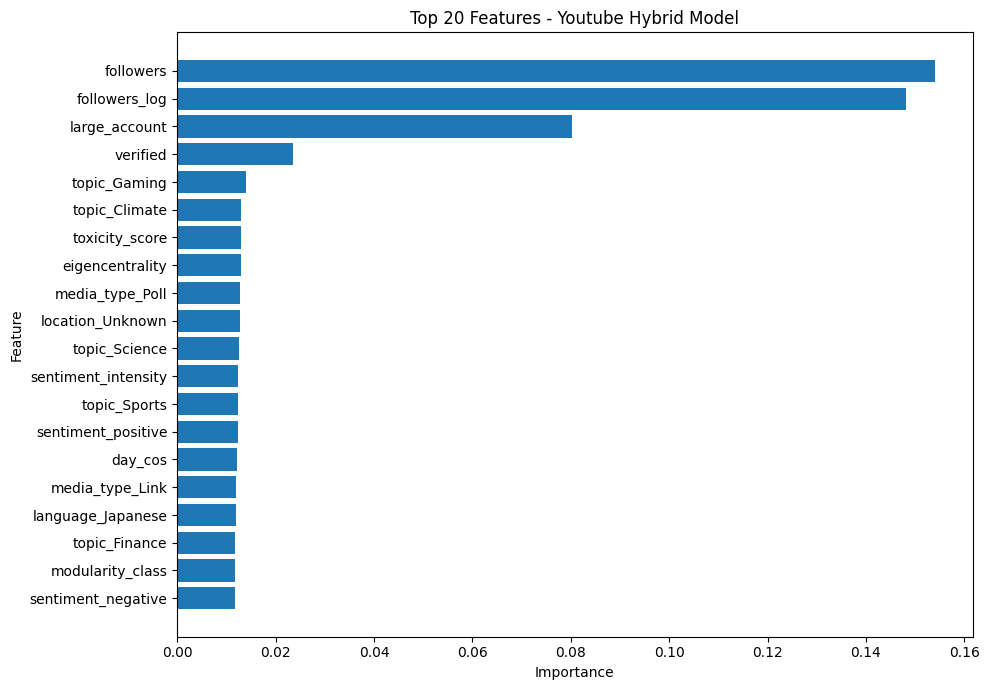

In [29]:
# PLOT TOP FEATURES
# =====================================================
import matplotlib.pyplot as plt

top_n = 20

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 20 Features - Youtube Hybrid Model"
)

plt.tight_layout()

plt.show()

# 2. YOUTUBE NODE2VEC

 GRAPH EMBEDDING

In [30]:
# LOAD GRAPH FEATURES FILE
# =====================================================
import pandas as pd

graph_df = pd.read_csv(
    "youtube-result-2.csv"
)

print("=" * 60)
print("GRAPH DATA")
print("=" * 60)

print(graph_df.shape)


GRAPH DATA
(18130, 16)


In [31]:
# CREATE NETWORKX GRAPH
# =====================================================

G = nx.Graph()

# =====================================================
# ADD NODES
# =====================================================

for idx, row in graph_df.iterrows():

    G.add_node(
        row["Id"]
    )

# =====================================================
# CREATE EDGES
# =====================================================
# IMPORTANT:
# Need original graph edge list
# =====================================================

# If you exported edge list from Gephi:
# load it here

edges_df = pd.read_csv(
    "youtube_edge.csv"
)

print("\nEdges Shape:")
print(edges_df.shape)

# =====================================================
# ADD EDGES
# =====================================================

for idx, row in edges_df.iterrows():

    source = row["Source"]
    target = row["Target"]

    # optional weight
    if "Weight" in edges_df.columns:

        G.add_edge(
            source,
            target,
            weight=row["Weight"]
        )

    else:

        G.add_edge(
            source,
            target
        )

print("\nGraph Created 🚀")

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())


Edges Shape:
(163104, 3)

Graph Created 🚀
Nodes: 18130
Edges: 163104


In [58]:
pip install "numpy>=2.1.0"

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [59]:
!pip install node2vec --no-deps

Defaulting to user installation because normal site-packages is not writeable
  Using cached node2vec-0.5.0-py3-none-any.whl.metadata (849 bytes)



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
!pip install gensim networkx joblib tqdm

Defaulting to user installation because normal site-packages is not writeable
  Using cached gensim-4.4.0-cp313-cp313-win_amd64.whl.metadata (8.6 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.4 MB ? eta -:--:--
   - -------------------------------------- 1.0/24.4 MB 3.8 MB/s eta 0:00:07
   --- ------------------------------------ 2.4/24.4 MB 5.0 MB/s eta 0:00:05
   ------ --------------------------------- 3.9/24.4 MB 5.9 MB/s eta 0:00:04
   --------- ------------------------------ 5.5/24.4 MB 6.2 MB/s eta 0:00:04
   --------- ------------------------------ 6.0/24.4 MB 6.3 MB/s eta 0:00:03
   ---------- ----------------------------- 6.3/24.4 MB 5.4 MB/s eta 0:00:04
   ---------- ----------------------------- 6.6/24.4 MB 4.9 MB/s eta 0:00:04
   ----------- ---------------------------- 6.8/24.4 MB 4.3 MB/s eta 0:00:05
   ------------ -----------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
node2vec 0.5.0 requires numpy<2.0.0,>=1.24.0, but you have numpy 2.3.3 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
# NODE2VEC
# =====================================================
from node2vec import Node2Vec


print("\n" + "=" * 60)
print("TRAINING NODE2VEC...")
print("=" * 60)

node2vec = Node2Vec(

    G,

    dimensions=32,

    walk_length=30,

    num_walks=50,

    workers=5,

    weight_key="weight",

    seed=42
)

model = node2vec.fit(

    window=5,

    min_count=1,

    batch_words=64
)

print("\nNode2Vec completed 🚀")



TRAINING NODE2VEC...


Computing transition probabilities:   0%|          | 0/18130 [00:00<?, ?it/s]


Node2Vec completed 🚀


In [33]:
# CREATE EMBEDDING DATAFRAME
# =====================================================

embeddings = []

for node in G.nodes():

    vector = model.wv[str(node)]

    row_data = {

        "post_id": node
    }

    # embedding dimensions
    for i in range(len(vector)):

        row_data[f"n2v_{i}"] = vector[i]

    embeddings.append(row_data)

embedding_df = pd.DataFrame(
    embeddings
)

print("\nEmbedding Shape:")
print(embedding_df.shape)


Embedding Shape:
(18130, 33)


In [34]:
# SAVE EMBEDDINGS
# =====================================================

embedding_df.to_csv(
    "youtube_node2vec_embeddings.csv",
    index=False
)

print("\nNode2Vec embeddings saved 🚀")


Node2Vec embeddings saved 🚀


In [35]:
# FACEBOOK NODE2VEC HYBRID MODEL
# METADATA + NODE2VEC EMBEDDINGS
# =====================================================

import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

import matplotlib.pyplot as plt

In [36]:
# LOAD TRAIN / TEST DATA
# =====================================================

train_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/youtube_train.csv"
)

test_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/youtube_test.csv"
)

print("=" * 60)
print("METADATA DATA")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

METADATA DATA
Train Shape: (14504, 58)
Test Shape : (3626, 58)


In [37]:
#LOAD NODE2VEC EMBEDDINGS
# =====================================================

embedding_df = pd.read_csv(
    "youtube_node2vec_embeddings.csv"
)

print("\n" + "=" * 60)
print("NODE2VEC EMBEDDINGS")
print("=" * 60)

print(embedding_df.shape)

print("\nEmbedding Columns:")
print(embedding_df.columns[:10])


NODE2VEC EMBEDDINGS
(18130, 33)

Embedding Columns:
Index(['post_id', 'n2v_0', 'n2v_1', 'n2v_2', 'n2v_3', 'n2v_4', 'n2v_5',
       'n2v_6', 'n2v_7', 'n2v_8'],
      dtype='object')


In [38]:
# MERGE TRAIN
# =====================================================

train_hybrid = train_df.merge(

    embedding_df,

    on="post_id",
    how="left"
)

# =====================================================
# MERGE TEST
# =====================================================

test_hybrid = test_df.merge(

    embedding_df,

    on="post_id",
    how="left"
)

# =====================================================
# CHECK MISSING VALUES
# =====================================================

print("\n" + "=" * 60)
print("MISSING EMBEDDINGS CHECK")
print("=" * 60)

embedding_cols = [

    col for col in embedding_df.columns
    if col.startswith("n2v_")
]

print("\nTrain Missing:")

print(
    train_hybrid[
        embedding_cols
    ].isnull().sum().sum()
)

print("\nTest Missing:")

print(
    test_hybrid[
        embedding_cols
    ].isnull().sum().sum()
)

# =====================================================
# FILL MISSING EMBEDDINGS
# =====================================================

train_hybrid[embedding_cols] = train_hybrid[
    embedding_cols
].fillna(0)

test_hybrid[embedding_cols] = test_hybrid[
    embedding_cols
].fillna(0)

# =====================================================
# DROP ID COLUMNS
# =====================================================

drop_cols = [

    "post_id",
    "user_id"
]

existing_drop_cols = [

    col for col in drop_cols
    if col in train_hybrid.columns
]

train_hybrid = train_hybrid.drop(
    columns=existing_drop_cols
)

test_hybrid = test_hybrid.drop(
    columns=existing_drop_cols
)


MISSING EMBEDDINGS CHECK

Train Missing:
0

Test Missing:
0


In [39]:
# SPLIT FEATURES / TARGET
# =====================================================

X_train = train_hybrid.drop(
    columns=["popularity"]
)

y_train = train_hybrid["popularity"]

X_test = test_hybrid.drop(
    columns=["popularity"]
)

y_test = test_hybrid["popularity"]

print("\n" + "=" * 60)
print("FINAL DATA")
print("=" * 60)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)



FINAL DATA
X_train: (14504, 87)
X_test : (3626, 87)


In [40]:
# =====================================================
# XGBOOST MODEL
# =====================================================
# Calculate class imbalance ratio
ratio = 11602 / 2902

# Initialize XGBoost with optimized parameters
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,     # Handle imbalanced data
    n_estimators=500,           # Number of boosting rounds
    learning_rate=0.02,         # Step size shrinkage
    max_depth=6,                # Maximum tree depth
    min_child_weight=1,         # Minimum sum of instance weight
    gamma=0.1,                  # Minimum loss reduction
    subsample=0.8,              # Fraction of training data per tree
    colsample_bytree=0.8,       # Fraction of features per tree
    random_state=42,            # For reproducibility
    n_jobs=-1                   # Use all CPU cores
)

# =====================================================
# TRAIN MODEL
# =====================================================

print("\n" + "=" * 60)
print("TRAINING NODE2VEC HYBRID MODEL...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)

print("Training completed 🚀")

# =====================================================
# PREDICTIONS
# =====================================================

import numpy as np
from sklearn.metrics import precision_recall_curve

# Get probability scores for the positive class
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate precision-recall pairs
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# Calculate F1-score for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

# Locate the threshold that yields the highest F1-score
best_threshold = thresholds[np.argmax(f1_scores)]

# Apply the optimal threshold to generate final predictions
y_pred = (y_prob >= best_threshold).astype(int)

# =====================================================
# EVALUATION
# =====================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


TRAINING NODE2VEC HYBRID MODEL...
Training completed 🚀


In [41]:
# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        digits=6
    )
)

print(f"ROC-AUC  : {roc_auc:.6f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0   0.927568  0.865219  0.895309      2901
           1   0.575000  0.729655  0.643161       725

    accuracy                       0.838114      3626
   macro avg   0.751284  0.797437  0.769235      3626
weighted avg   0.857074  0.838114  0.844894      3626

ROC-AUC  : 0.896006


In [42]:
# FEATURE IMPORTANCE
# =====================================================

importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(20)
)


TOP 20 IMPORTANT FEATURES
                feature  importance
21        large_account    0.121364
3             followers    0.117108
15        followers_log    0.099339
5              verified    0.052171
54     location_Unknown    0.011656
29         topic_Gaming    0.010500
2            is_weekend    0.009727
46      media_type_Poll    0.009308
10       toxicity_score    0.009220
40       language_Hindi    0.008969
32        topic_Science    0.008968
83               n2v_28    0.008503
24      topic_Education    0.008455
33         topic_Sports    0.008317
80               n2v_25    0.008292
43  language_Portuguese    0.008269
56                n2v_1    0.008201
13              day_sin    0.008147
37     language_English    0.008134
74               n2v_19    0.008077


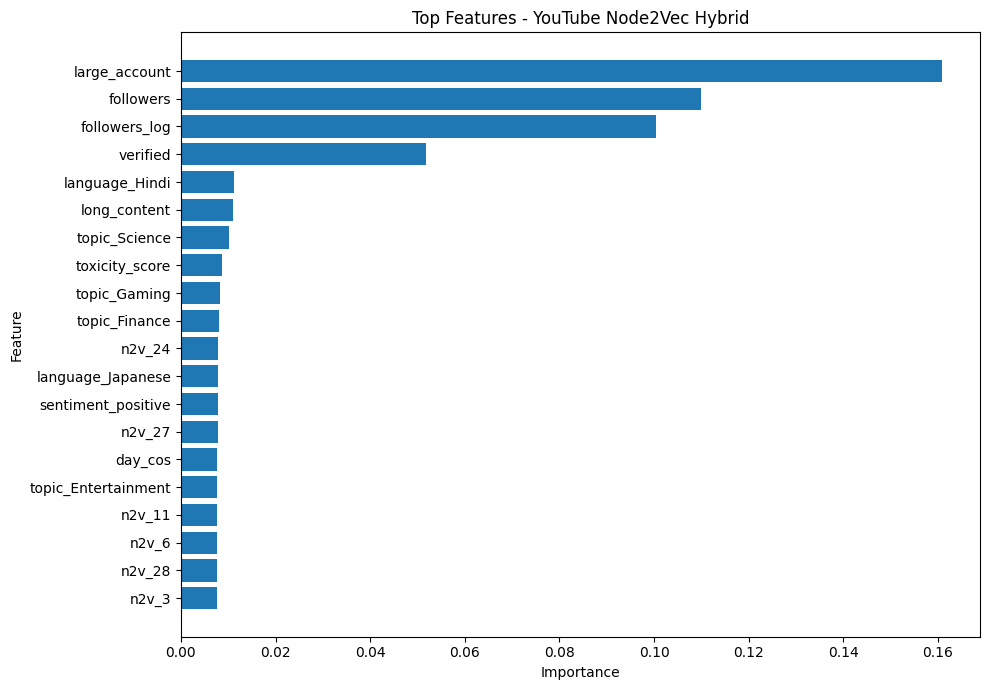

In [139]:
# =====================================================

top_n = 20

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top Features - YouTube Node2Vec Hybrid"
)

plt.tight_layout()

plt.show()

# 3. Youtube graph + Node2vector

In [43]:
train_df = pd.read_csv(
    "youtube_hybrid_train.csv"
)

test_df = pd.read_csv(
    "youtube_hybrid_test.csv"
)

print("=" * 60)
print("GRAPH HYBRID DATA")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

# =====================================================
# LOAD NODE2VEC EMBEDDINGS
# =====================================================

embedding_df = pd.read_csv(
    "youtube_node2vec_embeddings.csv"
)

print("\n" + "=" * 60)
print("NODE2VEC EMBEDDINGS")
print("=" * 60)

print(embedding_df.shape)

# =====================================================
# CHECK EMBEDDING KEY
# =====================================================

print("\nEmbedding Columns:")
print(embedding_df.columns[:5])


GRAPH HYBRID DATA
Train Shape: (14504, 62)
Test Shape : (3626, 62)

NODE2VEC EMBEDDINGS
(18130, 33)

Embedding Columns:
Index(['post_id', 'n2v_0', 'n2v_1', 'n2v_2', 'n2v_3'], dtype='object')


In [44]:
# MERGE NODE2VEC INTO TRAIN
# =====================================================

train_final = train_df.merge(

    embedding_df,

    on="post_id",

    how="left"
)

# =====================================================
# MERGE NODE2VEC INTO TEST
# =====================================================

test_final = test_df.merge(

    embedding_df,

    on="post_id",

    how="left"
)

print("\n" + "=" * 60)
print("AFTER MERGE")
print("=" * 60)

print("Train Shape:", train_final.shape)
print("Test Shape :", test_final.shape)



AFTER MERGE
Train Shape: (14504, 94)
Test Shape : (3626, 94)


In [45]:
# CHECK MISSING EMBEDDINGS
# =====================================================

embedding_cols = [

    col for col in embedding_df.columns
    if col.startswith("n2v_")
]

print("\nMissing Train Embeddings:")

print(
    train_final[
        embedding_cols
    ].isnull().sum().sum()
)

print("\nMissing Test Embeddings:")

print(
    test_final[
        embedding_cols
    ].isnull().sum().sum()
)

# =====================================================
# FILL MISSING VALUES
# =====================================================

train_final[embedding_cols] = train_final[
    embedding_cols
].fillna(0)

test_final[embedding_cols] = test_final[
    embedding_cols
].fillna(0)

# =====================================================
# DROP ID COLUMNS
# =====================================================

drop_cols = [

    "post_id",
    "user_id"
]

existing_drop_cols = [

    col for col in drop_cols
    if col in train_final.columns
]

train_final = train_final.drop(
    columns=existing_drop_cols
)

test_final = test_final.drop(
    columns=existing_drop_cols
)



Missing Train Embeddings:
0

Missing Test Embeddings:
0


In [46]:
# SPLIT FEATURES / TARGET
# =====================================================

X_train = train_final.drop(
    columns=["popularity"]
)

y_train = train_final["popularity"]

X_test = test_final.drop(
    columns=["popularity"]
)

y_test = test_final["popularity"]

print("\n" + "=" * 60)
print("FINAL FEATURE SPACE")
print("=" * 60)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


FINAL FEATURE SPACE
X_train: (14504, 91)
X_test : (3626, 91)


In [47]:
# XGBOOST MODEL
# =====================================================
# Calculate class imbalance ratio
ratio = 11602 / 2902

# Initialize XGBoost with optimized parameters
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,     # Handle imbalanced data
    n_estimators=500,           # Number of boosting rounds
    learning_rate=0.02,         # Step size shrinkage
    max_depth=6,                # Maximum tree depth
    min_child_weight=1,         # Minimum sum of instance weight
    gamma=0.1,                  # Minimum loss reduction
    subsample=0.8,              # Fraction of training data per tree
    colsample_bytree=0.8,       # Fraction of features per tree
    random_state=42,            # For reproducibility
    n_jobs=-1                   # Use all CPU cores
)

# =====================================================
# TRAIN MODEL
# =====================================================

print("\n" + "=" * 60)
print("TRAINING FINAL FACEBOOK HYBRID...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)

print("\nTraining completed 🚀")

# =====================================================
# PREDICTIONS
# =====================================================
import numpy as np
from sklearn.metrics import precision_recall_curve

# Get probability scores for the positive class
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate precision-recall pairs
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# Calculate F1-score for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

# Locate the threshold that yields the highest F1-score
best_threshold = thresholds[np.argmax(f1_scores)]

# Apply the optimal threshold to generate final predictions
y_pred = (y_prob >= best_threshold).astype(int)


TRAINING FINAL FACEBOOK HYBRID...

Training completed 🚀


In [48]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


In [50]:


print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        digits=6
    )
)
print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0   0.923440  0.877284  0.899770      2901
           1   0.590805  0.708966  0.644514       725

    accuracy                       0.843629      3626
   macro avg   0.757122  0.793125  0.772142      3626
weighted avg   0.856931  0.843629  0.848733      3626

ROC-AUC  : 0.8956


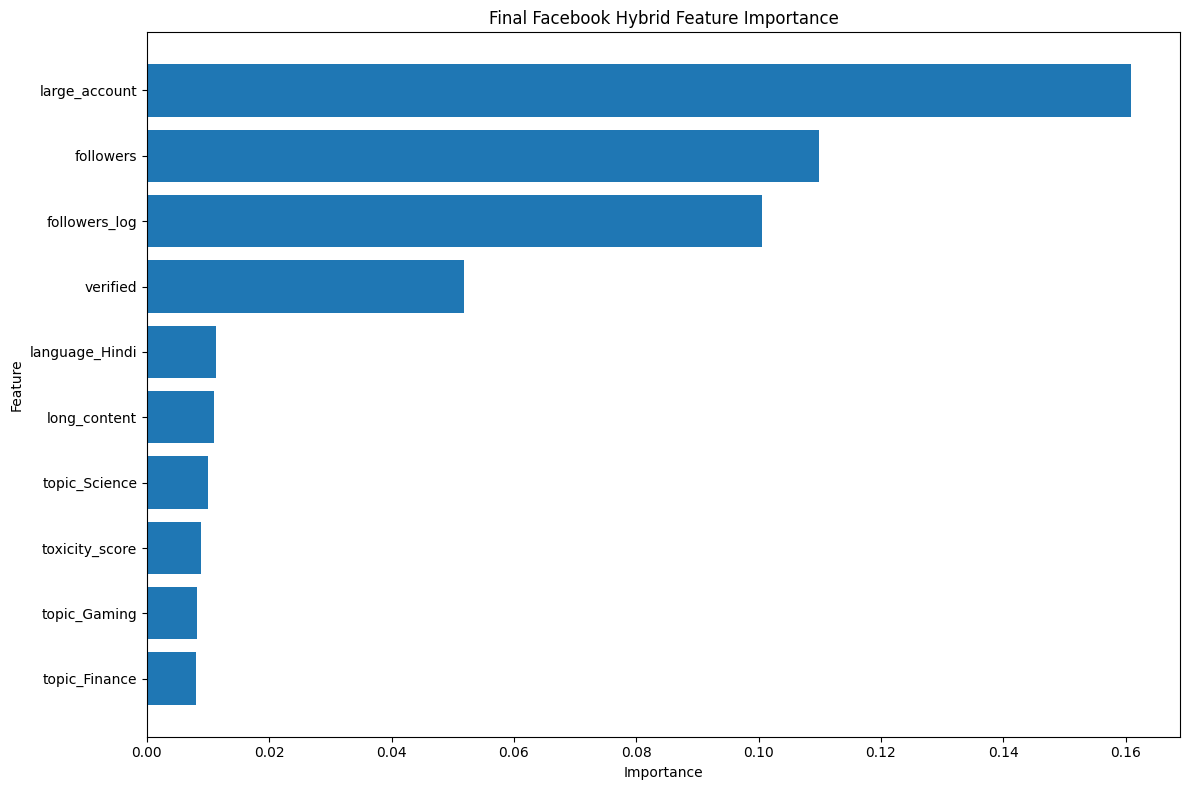

In [144]:
# PLOT FEATURE IMPORTANCE
# =====================================================

top_n = 10

plot_df = importance_df.head(top_n)

plt.figure(figsize=(12, 8))

plt.barh(

    plot_df["feature"][::-1],

    plot_df["importance"][::-1]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title(
    "Final Facebook Hybrid Feature Importance"
)

plt.tight_layout()

plt.show()